# GammaForge IO Module - Hands-On Exploration

This notebook lets you **feel** how the IO module works by:
- Creating electron beams with different physical parameters
- Sampling macroparticles from beam descriptions
- Propagating beams through vacuum
- Fitting macroparticles back to beam parameters
- Building a laser pulse and running the fast analytical model

All physical inputs on `GaussianElectronBeam`/`GaussianParaxialLaser` are
`PhysicalQuantity` (value + unit + physical meaning + convention, e.g.
RMS vs FWHM) -- the GUI wraps its own raw floats the same way at its own
boundary (see `gammaforge/gui/app.py`'s `_pq` helper), no intermediate
factory function.


In [1]:
import numpy as np
import pint

ureg = pint.UnitRegistry(system='cgs')
Q_ = ureg.Quantity

In [2]:
%matplotlib widget
import matplotlib.pyplot as plt


In [3]:
from scipy.fft import fft, fftfreq, fftshift, rfft

In [4]:
xs = np.linspace(-14.0, 26.0, 512)
ys = np.exp(-xs**2/2) / np.sqrt(2*np.pi)

In [5]:
np.trapezoid(ys,xs)

np.float64(1.0000000000000002)

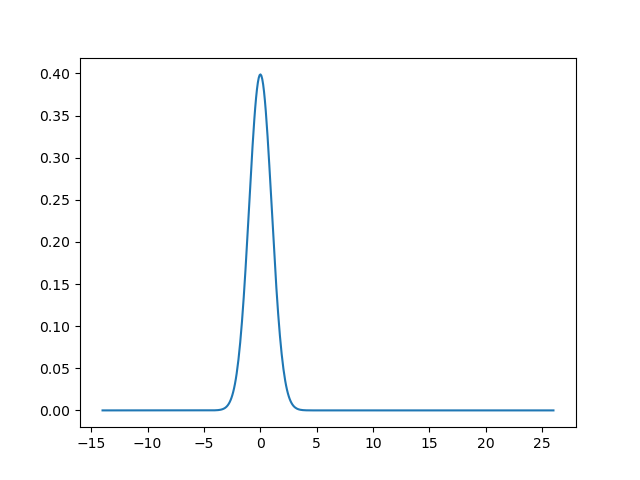

In [6]:
fig,ax=plt.subplots()
ax.plot(xs,ys)

In [7]:
fft_y = fft(ys)
fft_x = fftfreq(xs.size, np.diff(xs)[0])

(-1.0, 1.0)

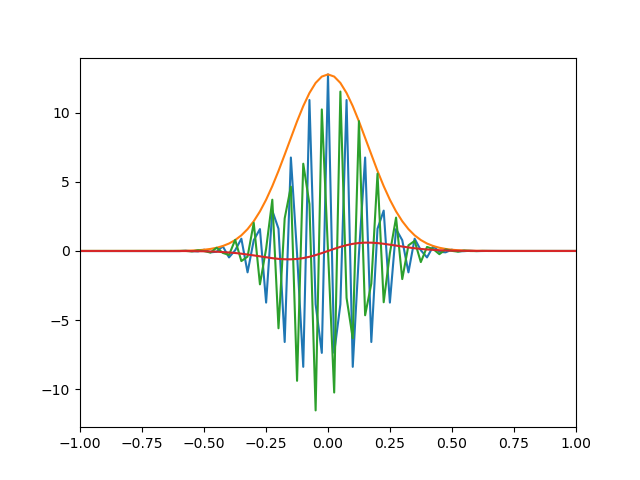

In [8]:
fig,ax = plt.subplots()
ax.plot(fftshift(fft_x),fftshift(np.real(fft_y)))
ax.plot(fftshift(fft_x),fftshift(np.real(fft_y*np.exp(1j*fft_x*(-xs[-1])*2*np.pi))))

ax.plot(fftshift(fft_x),fftshift(np.imag(fft_y)))
ax.plot(fftshift(fft_x),fftshift(np.imag(fft_y*np.exp(1j*fft_x*(-xs[-1])*2*np.pi))))

ax.set_xlim(-1,1)

In [9]:
Q_(1, "vacuum_permittivity").to_base_units()

<Quantity(8.85418782e-21, 'ampere ** 2 * second ** 4 / gram / centimeter ** 3')>

In [10]:
Np = 1024

length_unit = "cm"

mx = Q_(1.0, "meter")
sx = Q_(0.1, "meter")

x = Q_(np.random.normal(mx.to(length_unit).magnitude, sx.to(length_unit).magnitude, Np), length_unit)
y = Q_(np.random.normal(1.0, 0.1, Np), "meter")

thx = Q_(np.random.normal(0.0, 0.1, Np), "radian")
thy = Q_(np.random.normal(0.0, 0.1, Np), "radian")


units = [x.u, thx.u, y.u, thy.u]
unit_matrix = [[units[i] * units[j] for j in range(4)] 
                   for i in range(4)]

X = np.stack([x.magnitude, thx.magnitude, y.magnitude, thy.magnitude], axis=1)

# Center data
mu = np.mean(X, axis=0)
Xc = X - mu

# Compute covariance (biased for population parameters)
Sigma = np.cov(Xc, rowvar=False, bias=True)

# Extract parameters
ix, ixp, iy, iyp = range(4)

# Transverse emittance
emit_x = Q_(np.sqrt(Sigma[ix, ix] * Sigma[ixp, ixp] - Sigma[ix, ixp]**2), x.u*thx.u)
emit_y = Q_(np.sqrt(Sigma[iy, iy] * Sigma[iyp, iyp] - Sigma[iy, iyp]**2), y.u*thy.u)

In [11]:
emit_x

<Quantity(1.03819497, 'centimeter * radian')>

In [12]:
import numpy as np
import matplotlib.pyplot as plt

from gammaforge.io.bunch import (
    GaussianElectronBeam, sample_gaussian_bunch, sample_gaussian_canonical,
    fit_gaussian, drift,
)
from gammaforge.io.units import (
    MEC2_EV, E_CHARGE, C_LIGHT, HBAR_Q,
    PhysicalQuantity, PhysicalMeaning, NoConvention, WidthConvention, TimeConvention,
)
from gammaforge.io.laser import GaussianParaxialLaser
from gammaforge.models.analytical import estimate_yield, estimate_spectrum_width, angle_integrated_spectrum

# Plotting style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12


def pq(value, unit, meaning, convention=NoConvention.PLAIN):
    """Shortcut to build a PhysicalQuantity -- same pattern the GUI uses
    at its own boundary (gui/app.py's `_pq`), no shared factory function."""
    return PhysicalQuantity(value, unit, meaning, convention)


## 1. Physical Constants

First, let's see the physical constants we're working with.

In [13]:
print("Physical Constants:")
print(f"  Electron rest mass energy: {MEC2_EV:.6f} eV")
print(f"  Elementary charge: {E_CHARGE:.6e} C")
print(f"  Speed of light: {C_LIGHT:.6e} m/s")
print(f"  m_e c^2 in MeV: {MEC2_EV/1e6:.6f} MeV")


Physical Constants:
  Electron rest mass energy: 510998.950692 eV
  Elementary charge: 1.602177e-19 C
  Speed of light: 2.997925e+08 m/s
  m_e c^2 in MeV: 0.510999 MeV


## 2. Creating Electron Beams

Let's create different electron beams and understand their parameters.

In [14]:
# Example 1: High-energy beam (like at LCLS)
beam_high_energy = GaussianElectronBeam(
    bunch_charge_C=pq(100e-12, "coulomb", PhysicalMeaning.BUNCH_CHARGE),           # 100 pC
    kinetic_energy_eV=pq(500e6, "electron_volt", PhysicalMeaning.BEAM_ENERGY),     # 500 MeV
    rel_energy_spread_rms=0.001,                                                   # 0.1% energy spread
    sigma_x_m=pq(100e-6, "meter", PhysicalMeaning.ELECTRON_BEAM_SIZE,
                 WidthConvention.SIGMA_INTENSITY_RMS),                             # 100 um beam size
    sigma_y_m=pq(100e-6, "meter", PhysicalMeaning.ELECTRON_BEAM_SIZE,
                 WidthConvention.SIGMA_INTENSITY_RMS),                             # 100 um beam size
    emit_geom_x_m=pq(10e-9, "meter", PhysicalMeaning.EMITTANCE),                   # 10 nm geometric emittance
    emit_geom_y_m=pq(10e-9, "meter", PhysicalMeaning.EMITTANCE),                   # 10 nm geometric emittance
    sigma_t_s=pq(1e-12, "second", PhysicalMeaning.BUNCH_LENGTH,
                 TimeConvention.SIGMA_INTENSITY_RMS),                              # 1 ps bunch duration
    sigma_pz=0.001,                                                                # 0.1% momentum spread
)

print("High-energy beam (500 MeV):")
print(f"  Gamma: {beam_high_energy.gamma0:.2f}")
print(f"  Beta: {beam_high_energy.beta0:.6f}")
print(f"  Number of electrons: {beam_high_energy.N_e:.2e}")
print(f"  Divergence x: {beam_high_energy.divergence_x_rad*1e3:.3f} mrad")
print(f"  Beta star x: {beam_high_energy.beta_star_x.to('millimeter').magnitude:.2f} mm")
print(f"  Peak current: {beam_high_energy.peak_current.to('ampere').magnitude:.2f} A")
print(f"  Peak density: {beam_high_energy.peak_density.to('1/meter**3').magnitude:.2e} m^-3")


High-energy beam (500 MeV):
  Gamma: 979.48
  Beta: 0.999999
  Number of electrons: 6.24e+08
  Divergence x: 0.100 mrad
  Beta star x: 1000.00 mm
  Peak current: 39.89 A
  Peak density: 1.32e+19 m^-3


In [15]:
# Example 2: Low-energy beam (like at FERMI)
beam_low_energy = GaussianElectronBeam(
    bunch_charge_C=pq(500e-12, "coulomb", PhysicalMeaning.BUNCH_CHARGE),           # 500 pC
    kinetic_energy_eV=pq(100e6, "electron_volt", PhysicalMeaning.BEAM_ENERGY),     # 100 MeV
    rel_energy_spread_rms=0.005,                                                   # 0.5% energy spread
    sigma_x_m=pq(50e-6, "meter", PhysicalMeaning.ELECTRON_BEAM_SIZE,
                 WidthConvention.SIGMA_INTENSITY_RMS),                             # 50 um beam size
    sigma_y_m=pq(50e-6, "meter", PhysicalMeaning.ELECTRON_BEAM_SIZE,
                 WidthConvention.SIGMA_INTENSITY_RMS),                             # 50 um beam size
    emit_geom_x_m=pq(1e-6, "meter", PhysicalMeaning.EMITTANCE),                    # 1 um geometric emittance
    emit_geom_y_m=pq(1e-6, "meter", PhysicalMeaning.EMITTANCE),                    # 1 um geometric emittance
    sigma_t_s=pq(0.5e-12, "second", PhysicalMeaning.BUNCH_LENGTH,
                 TimeConvention.SIGMA_INTENSITY_RMS),                              # 0.5 ps bunch duration
    sigma_pz=0.005,                                                                # 0.5% momentum spread
)

print("Low-energy beam (100 MeV):")
print(f"  Gamma: {beam_low_energy.gamma0:.2f}")
print(f"  Beta: {beam_low_energy.beta0:.6f}")
print(f"  Number of electrons: {beam_low_energy.N_e:.2e}")
print(f"  Divergence x: {beam_low_energy.divergence_x_rad*1e3:.3f} mrad")
print(f"  Beta star x: {beam_low_energy.beta_star_x.to('millimeter').magnitude:.2f} mm")


Low-energy beam (100 MeV):
  Gamma: 196.70
  Beta: 0.999987
  Number of electrons: 3.12e+09
  Divergence x: 20.000 mrad
  Beta star x: 2.50 mm


## 3. Sampling Macroparticles

Now let's sample macroparticles from the beam description. This is where the **canonical sampling** with mass-shell enforcement happens.

In [16]:
# Sample from the high-energy beam
rng = np.random.default_rng(42)
n_particles = 10000

bunch_high = sample_gaussian_bunch(beam_high_energy, n_particles, rng=rng)

print(f"Sampled {bunch_high.n_particles} particles")
print(f"Total charge: {bunch_high.n_electrons * E_CHARGE:.2e} C")
print(f"Weight per particle: {bunch_high.weight:.2e} electrons/macroparticle")

# Check mass-shell constraint (pz is *derived*, never independently sampled --
# see AGENTS.md's "Electron sampling" section)
pz = np.sqrt((bunch_high.gamma**2 - 1) / (1 + bunch_high.thx**2 + bunch_high.thy**2))
px = bunch_high.thx * pz
py = bunch_high.thy * pz

gamma_sq = bunch_high.gamma**2
p_sq = 1.0 + px**2 + py**2 + pz**2

print(f"\nMass-shell check (gamma^2 vs 1+p^2):")
print(f"  Max relative error: {np.max(np.abs(gamma_sq - p_sq) / gamma_sq):.2e}")

# sample_gaussian_bunch attaches the exact input beam as the fit -- a
# freshly-drawn sample matches it exactly, no fit needed
print(f"\nbunch_high.gaussian_fit is beam_high_energy: {bunch_high.gaussian_fit is beam_high_energy}")


Sampled 10000 particles
Total charge: 1.00e-10 C
Weight per particle: 6.24e+04 electrons/macroparticle

Mass-shell check (gamma^2 vs 1+p^2):
  Max relative error: 3.66e-16

bunch_high.gaussian_fit is beam_high_energy: True


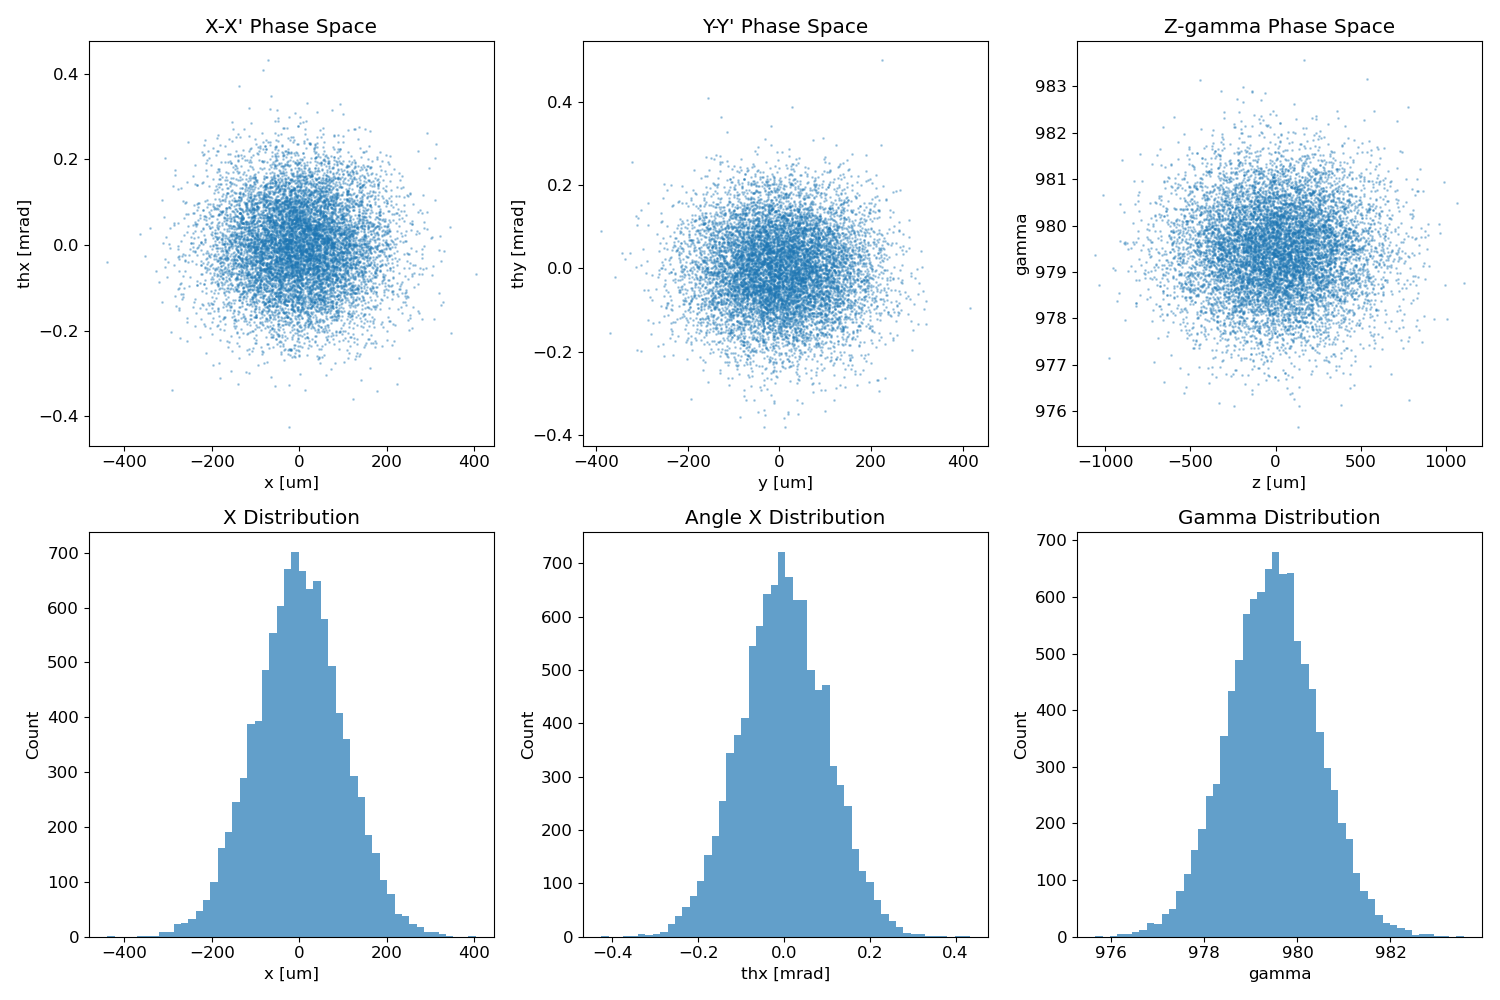

In [17]:
# Visualize the sampled bunch
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Transverse phase space
axes[0, 0].scatter(bunch_high.x * 1e6, bunch_high.thx * 1e3, s=1, alpha=0.3)
axes[0, 0].set_xlabel('x [um]')
axes[0, 0].set_ylabel('thx [mrad]')
axes[0, 0].set_title('X-X\' Phase Space')

axes[0, 1].scatter(bunch_high.y * 1e6, bunch_high.thy * 1e3, s=1, alpha=0.3)
axes[0, 1].set_xlabel('y [um]')
axes[0, 1].set_ylabel('thy [mrad]')
axes[0, 1].set_title('Y-Y\' Phase Space')

# Longitudinal phase space
axes[0, 2].scatter(bunch_high.z * 1e6, bunch_high.gamma, s=1, alpha=0.3)
axes[0, 2].set_xlabel('z [um]')
axes[0, 2].set_ylabel('gamma')
axes[0, 2].set_title('Z-gamma Phase Space')

# Histograms
axes[1, 0].hist(bunch_high.x * 1e6, bins=50, alpha=0.7)
axes[1, 0].set_xlabel('x [um]')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('X Distribution')

axes[1, 1].hist(bunch_high.thx * 1e3, bins=50, alpha=0.7)
axes[1, 1].set_xlabel('thx [mrad]')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Angle X Distribution')

axes[1, 2].hist(bunch_high.gamma, bins=50, alpha=0.7)
axes[1, 2].set_xlabel('gamma')
axes[1, 2].set_ylabel('Count')
axes[1, 2].set_title('Gamma Distribution')

plt.tight_layout()
plt.show()

## 4. Fitting Macroparticles Back to Beam Parameters

Let's see how well we can recover the original beam parameters from the sampled macroparticles.

In [18]:
# Fit a GaussianElectronBeam back from the raw macroparticles: full
# covariance-based Twiss/chirp/dispersion fit, handles nonzero alpha_x/
# alpha_y (unlike an old waist-only trick) -- there's only one fitting
# function now, fit_gaussian (no separate "simple" vs "full" fit).
fit = fit_gaussian(bunch_high)

print("Fitted GaussianElectronBeam (fit_gaussian):")
print(f"  sigma_x: {fit.sigma_x_m.to_unit('meter').magnitude*1e6:.2f} um "
      f"(input: {beam_high_energy.sigma_x_m.to_unit('meter').magnitude*1e6:.2f} um)")
print(f"  sigma_y: {fit.sigma_y_m.to_unit('meter').magnitude*1e6:.2f} um "
      f"(input: {beam_high_energy.sigma_y_m.to_unit('meter').magnitude*1e6:.2f} um)")
print(f"  emit_x: {fit.emit_geom_x_m.to_unit('meter').magnitude*1e9:.2f} nm "
      f"(input: {beam_high_energy.emit_geom_x_m.to_unit('meter').magnitude*1e9:.2f} nm)")
print(f"  emit_y: {fit.emit_geom_y_m.to_unit('meter').magnitude*1e9:.2f} nm "
      f"(input: {beam_high_energy.emit_geom_y_m.to_unit('meter').magnitude*1e9:.2f} nm)")
print(f"  gamma0: {fit.gamma0:.2f} (input: {beam_high_energy.gamma0:.2f})")
print(f"  alpha_x: {fit.alpha_x:.4f} (should be ~0 -- sampled at its own waist)")
print(f"  alpha_y: {fit.alpha_y:.4f} (should be ~0 -- sampled at its own waist)")


Fitted GaussianElectronBeam (fit_gaussian):
  sigma_x: 100.63 um (input: 100.00 um)
  sigma_y: 100.28 um (input: 100.00 um)
  emit_x: 10.12 nm (input: 10.00 nm)
  emit_y: 9.98 nm (input: 10.00 nm)
  gamma0: 979.47 (input: 979.48)
  alpha_x: 0.0019 (should be ~0 -- sampled at its own waist)
  alpha_y: 0.0101 (should be ~0 -- sampled at its own waist)


In [19]:
# Fit quality metrics -- Mahalanobis distance, KS statistics, log-likelihood,
# comparing the real data against synthetic Gaussian samples at the fitted
# parameters (see evaluate_fit_quality)
print("Fit quality metrics:")
for key, value in fit.fit_quality.items():
    print(f"  {key}: {value:.4f}")


Fit quality metrics:
  ks_real: 0.0055
  ks_synthetic: 0.0062
  ks_excess: -0.0007
  mean_d2_real: 6.0000
  mean_d2_synthetic: 6.0071
  log_likelihood_real: 36.4499
  log_likelihood_synthetic: 36.4464


In [20]:
# (fit_quality already printed above -- fit_gaussian does the full
# covariance-based fit in one call, no separate "simple" vs "full" step.)


## 5. Propagating Beams with Drift

Let's see how the beam evolves as it propagates through vacuum. This is where the **Twiss tilt** naturally emerges from waist sampling.

At waist: alpha_x = 0.0000, alpha_y = 0.0000
After 10 cm drift: alpha_x = -0.1000, alpha_y = -0.1000
Cross-check via fit_gaussian: alpha_x = -0.1095, alpha_y = -0.1129


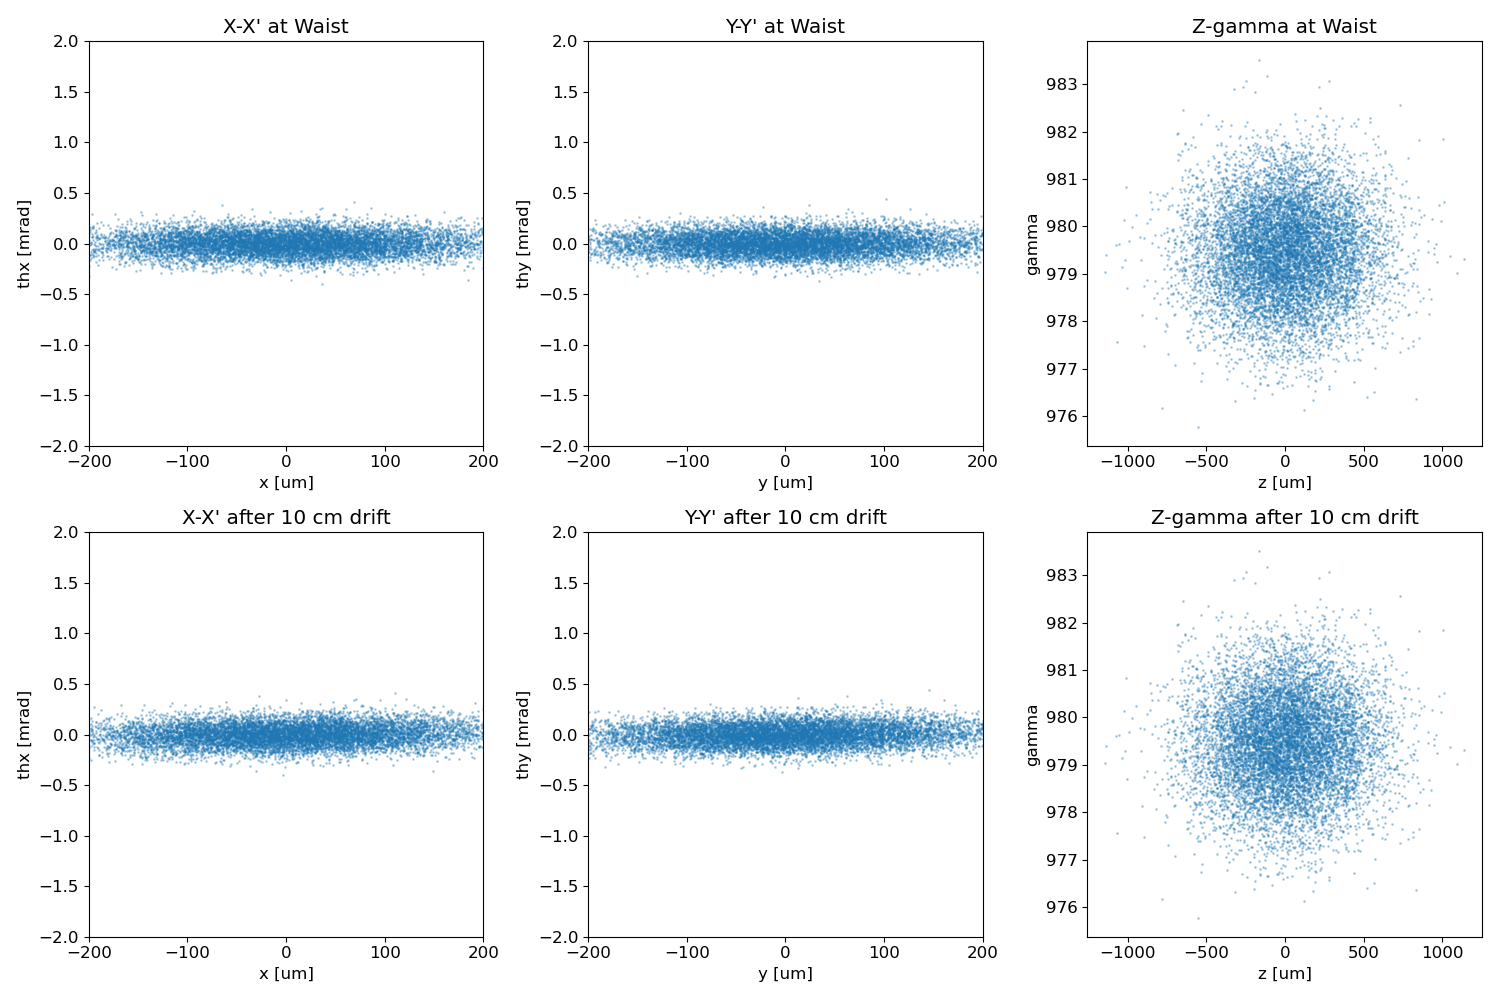

In [21]:
# Sample at waist
rng2 = np.random.default_rng(123)
bunch_waist = sample_gaussian_canonical(beam_high_energy, 10000, rng=rng2)
print(f"At waist: alpha_x = {bunch_waist.gaussian_fit.alpha_x:.4f}, "
      f"alpha_y = {bunch_waist.gaussian_fit.alpha_y:.4f}")

# Drift 10 cm -- drift() analytically updates the attached gaussian_fit's
# alpha_x/alpha_y in lockstep with the macroparticles (closed-form
# Twiss-drift relation), no refit needed
L = 0.1  # 10 cm
bunch_drifted = drift(bunch_waist, L)
print(f"After {L*100:.0f} cm drift: alpha_x = {bunch_drifted.gaussian_fit.alpha_x:.4f}, "
      f"alpha_y = {bunch_drifted.gaussian_fit.alpha_y:.4f}")

# Cross-check: an independent fit_gaussian() on the drifted macroparticles
# should agree with the analytically-updated gaussian_fit above
refit_drifted = fit_gaussian(bunch_drifted)
print(f"Cross-check via fit_gaussian: alpha_x = {refit_drifted.alpha_x:.4f}, "
      f"alpha_y = {refit_drifted.alpha_y:.4f}")

# Visualize the evolution
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# At waist
axes[0, 0].scatter(bunch_waist.x * 1e6, bunch_waist.thx * 1e3, s=1, alpha=0.3)
axes[0, 0].set_xlabel('x [um]')
axes[0, 0].set_ylabel('thx [mrad]')
axes[0, 0].set_title('X-X\' at Waist')
axes[0, 0].set_xlim(-200, 200)
axes[0, 0].set_ylim(-2, 2)

axes[0, 1].scatter(bunch_waist.y * 1e6, bunch_waist.thy * 1e3, s=1, alpha=0.3)
axes[0, 1].set_xlabel('y [um]')
axes[0, 1].set_ylabel('thy [mrad]')
axes[0, 1].set_title('Y-Y\' at Waist')
axes[0, 1].set_xlim(-200, 200)
axes[0, 1].set_ylim(-2, 2)

axes[0, 2].scatter(bunch_waist.z * 1e6, bunch_waist.gamma, s=1, alpha=0.3)
axes[0, 2].set_xlabel('z [um]')
axes[0, 2].set_ylabel('gamma')
axes[0, 2].set_title('Z-gamma at Waist')

# After drift
axes[1, 0].scatter(bunch_drifted.x * 1e6, bunch_drifted.thx * 1e3, s=1, alpha=0.3)
axes[1, 0].set_xlabel('x [um]')
axes[1, 0].set_ylabel('thx [mrad]')
axes[1, 0].set_title(f'X-X\' after {L*100:.0f} cm drift')
axes[1, 0].set_xlim(-200, 200)
axes[1, 0].set_ylim(-2, 2)

axes[1, 1].scatter(bunch_drifted.y * 1e6, bunch_drifted.thy * 1e3, s=1, alpha=0.3)
axes[1, 1].set_xlabel('y [um]')
axes[1, 1].set_ylabel('thy [mrad]')
axes[1, 1].set_title(f'Y-Y\' after {L*100:.0f} cm drift')
axes[1, 1].set_xlim(-200, 200)
axes[1, 1].set_ylim(-2, 2)

axes[1, 2].scatter(bunch_drifted.z * 1e6, bunch_drifted.gamma, s=1, alpha=0.3)
axes[1, 2].set_xlabel('z [um]')
axes[1, 2].set_ylabel('gamma')
axes[1, 2].set_title(f'Z-gamma after {L*100:.0f} cm drift')

plt.tight_layout()
plt.show()


## 6. Laser Parameters

Let's also look at the laser parameters needed for Compton scattering.

In [22]:
# Create a laser pulse
laser = GaussianParaxialLaser(
    pulse_energy_J=pq(0.5, "joule", PhysicalMeaning.PULSE_ENERGY),                     # 0.5 J
    wavelength_m=pq(0.8e-6, "meter", PhysicalMeaning.WAVELENGTH),                      # 800 nm (Ti:Sapphire)
    waist_rms_x_m=pq(25e-6, "meter", PhysicalMeaning.LASER_WIDTH,
                      WidthConvention.SIGMA_INTENSITY_RMS),                            # 25 um waist
    waist_rms_y_m=pq(25e-6, "meter", PhysicalMeaning.LASER_WIDTH,
                      WidthConvention.SIGMA_INTENSITY_RMS),                            # 25 um waist
    duration_rms_s=pq(30e-15, "second", PhysicalMeaning.PULSE_DURATION,
                       TimeConvention.SIGMA_INTENSITY_RMS),                            # 30 fs duration
    focus_z_m=pq(0.0, "meter", PhysicalMeaning.DISPLACEMENT),                          # focus at IP
)

photon_energy_eV = (HBAR_Q * laser.omega0).to("electron_volt").magnitude

print("Laser parameters:")
print(f"  Wavelength: {laser.wavelength_m.to_unit('nanometer').magnitude:.0f} nm")
print(f"  Photon energy: {photon_energy_eV:.2f} eV")
print(f"  Pulse energy: {laser.pulse_energy_J.to_unit('joule').magnitude:.2f} J")
print(f"  Peak power: {laser.peak_power.to('terawatt').magnitude:.2f} TW")
print(f"  Waist x: {laser.waist_rms_x_m.to_unit('micrometer').magnitude:.1f} um")
print(f"  Waist y: {laser.waist_rms_y_m.to_unit('micrometer').magnitude:.1f} um")
print(f"  Duration: {laser.duration_rms_s.to_unit('femtosecond').magnitude:.1f} fs")
print(f"  Rayleigh range x: {laser.rayleigh_x.to('millimeter').magnitude:.2f} mm")
print(f"  Peak intensity (at focus): {laser.peak_intensity_focus.to('watt/meter**2').magnitude:.2e} W/m^2")
print(f"  Peak a0 (at focus): {laser.a0_focus:.2f}")
print(f"  Photons per pulse: {laser.n_photons:.2e}")


Laser parameters:
  Wavelength: 800 nm
  Photon energy: 1.55 eV
  Pulse energy: 0.50 J
  Peak power: 6.65 TW
  Waist x: 25.0 um
  Waist y: 25.0 um
  Duration: 30.0 fs
  Rayleigh range x: 9.82 mm
  Peak intensity (at focus): 1.69e+21 W/m^2
  Peak a0 (at focus): 0.28
  Photons per pulse: 2.01e+18


## 7. Running the Analytical Model

The `analytical` module (`gammaforge.models.analytical`) has no `Config`
class or per-model bundle -- `estimate_yield`/`estimate_spectrum_width`
take the shared `GaussianElectronBeam`/`GaussianParaxialLaser` directly.
(There used to be a CGS `CollisionParams` bundle here for xigma-i/delta --
it was removed; those models now convert exactly what they need from the
shared beam/laser at their own call sites instead, see
`models/xigma_i/config.py`'s module docstring.)


In [23]:
# Run the fast closed-form model directly on the beam/laser above --
# no per-particle Monte Carlo, meant for sanity-checking a real computation
yield_est = estimate_yield(beam_high_energy, laser)
print(f"Estimated photon yield: {yield_est:.2e} photons/pulse")

theta_col = 1e-3  # 1 mrad collimation half-angle
width_est = estimate_spectrum_width(beam_high_energy, laser, theta_col=theta_col)
print(f"Estimated collimated spectrum FWHM: {width_est:.3f} (units of the Compton edge)")


Estimated photon yield: 1.25e+06 photons/pulse
Estimated collimated spectrum FWHM: 1.131 (units of the Compton edge)


## 8. Angle-Integrated Spectrum Shape

`angle_integrated_spectrum` gives the angle-integrated dN/ds *shape*
(s = E/E_max) directly from a sampled bunch's `gamma`/`weight` arrays --
no table, no quadrature. It is the standard Compton-edge shape only, not
scaled by the physical cross-section/luminosity factor that turns it into
an absolute photon count, so its integral is **not** directly comparable
in magnitude to `estimate_yield`'s photons/pulse -- it is a shape check,
not an absolute yield.


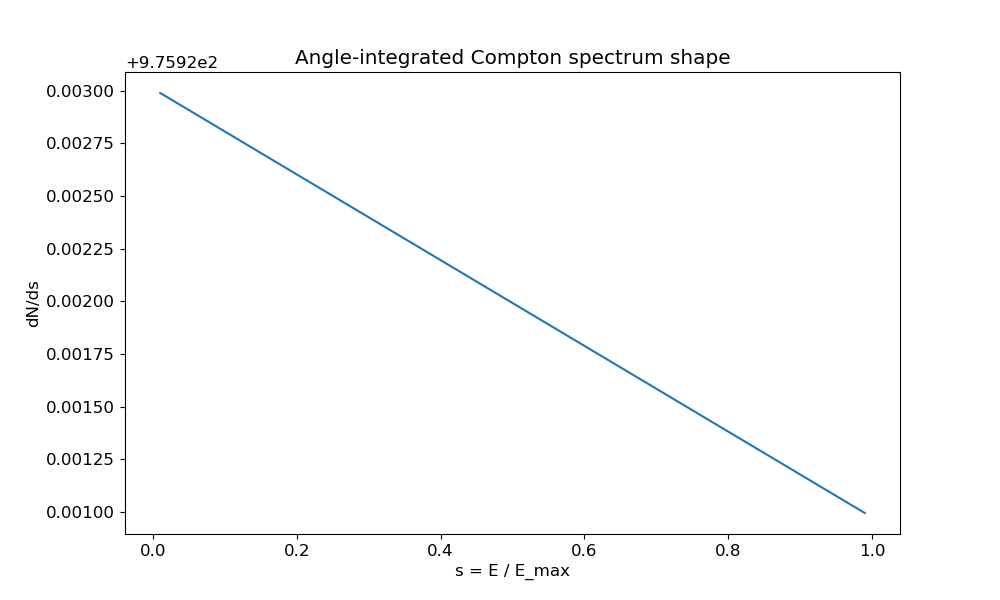

In [24]:
# Sample a bunch to drive the spectrum shape
rng3 = np.random.default_rng(456)
bunch_for_model = sample_gaussian_bunch(beam_high_energy, 10000, rng=rng3)

s_grid = np.linspace(0.01, 0.99, 200)
dNds = angle_integrated_spectrum(
    bunch_for_model.gamma,
    np.full(bunch_for_model.n_particles, bunch_for_model.weight),
    s_grid,
)

fig, ax = plt.subplots()
ax.plot(s_grid, dNds)
ax.set_xlabel("s = E / E_max")
ax.set_ylabel("dN/ds")
ax.set_title("Angle-integrated Compton spectrum shape")
plt.show()


In [25]:
print(f"Integral of the (unscaled) spectrum shape over s: {np.trapezoid(dNds, s_grid):.3e}")
print("(Not directly comparable to the photons/pulse yield_est above -- "
      "angle_integrated_spectrum returns a shape, not an absolute count.)")


Integral of the (unscaled) spectrum shape over s: 9.564e+02
(Not directly comparable to the photons/pulse yield_est above -- angle_integrated_spectrum returns a shape, not an absolute count.)


## 9. Data Flow Summary

Let's summarize the complete data flow:

```
1. GaussianElectronBeam (analytic description)
   ↓
2. sample_gaussian_bunch() → MacroBunch (macroparticles)
   ↓
3. drift() → MacroBunch (propagated)
   ↓
4. fit_beam_full() → BeamFittedParams (recovered parameters)
   ↓
5. model.run() → CommonResults (physics output)
```

In [26]:
# Complete data flow example
print("=" * 60)
print("COMPLETE DATA FLOW EXAMPLE")
print("=" * 60)

# Step 1: Create beam
print("\n1. Created GaussianElectronBeam:")
print(f"   gamma0 = {beam_high_energy.gamma0:.2f}")
print(f"   sigma_x = {beam_high_energy.sigma_x_m.to_unit('meter').magnitude*1e6:.1f} um")
print(f"   emit_x = {beam_high_energy.emit_geom_x_m.to_unit('meter').magnitude*1e9:.1f} nm")

# Step 2: Sample bunch
print("\n2. Sampled Bunch:")
print(f"   n_particles = {bunch_for_model.n_particles}")
print(f"   weight = {bunch_for_model.weight:.2e}")

# Step 3: Drift
print("\n3. Drifted 10 cm:")
bunch_final = drift(bunch_for_model, 0.1)
print(f"   sigma_x increased from {np.std(bunch_for_model.x)*1e6:.1f} to {np.std(bunch_final.x)*1e6:.1f} um")

# Step 4: Fit
print("\n4. Fitted GaussianElectronBeam (fit_gaussian):")
params_final = fit_gaussian(bunch_final)
print(f"   sigma_x = {params_final.sigma_x_m.to_unit('meter').magnitude*1e6:.1f} um")
print(f"   emit_x = {params_final.emit_geom_x_m.to_unit('meter').magnitude*1e9:.1f} nm")
print(f"   alpha_x = {params_final.alpha_x:.4f}")

# Step 5: Physics (closed-form estimates)
print("\n5. Analytical model estimates:")
print(f"   Yield = {yield_est:.2e} photons/pulse")
print(f"   Collimated spectrum FWHM = {width_est:.3f} (units of Compton edge)")

print("\n" + "=" * 60)


COMPLETE DATA FLOW EXAMPLE

1. Created GaussianElectronBeam:
   gamma0 = 979.48
   sigma_x = 100.0 um
   emit_x = 10.0 nm

2. Sampled Bunch:
   n_particles = 10000
   weight = 6.24e+04

3. Drifted 10 cm:


   sigma_x increased from 100.3 to 100.8 um

4. Fitted GaussianElectronBeam (fit_gaussian):
   sigma_x = 100.3 um
   emit_x = 10.1 nm
   alpha_x = -0.1002

5. Analytical model estimates:
   Yield = 1.25e+06 photons/pulse
   Collimated spectrum FWHM = 1.131 (units of Compton edge)



## 10. Experiments to Try

Here are some experiments you can try:

1. **Vary sigma_pz**: See how the energy spread affects the sampling and fitting
2. **Different emittances**: Try with larger/smaller emittance values
3. **Longer drifts**: See how the beam evolves over larger distances
4. **Different energies**: Compare high-energy vs low-energy beams
5. **Fit quality**: Check how the KS and log-likelihood metrics change with different parameters

Just modify the parameters in the cells above and re-run to explore!

In [27]:
# Experiment: Vary sigma_pz and see the effect
print("Effect of sigma_pz on energy spread:\n")

sigma_pz_values = [0.001, 0.005, 0.01, 0.05]

for spz in sigma_pz_values:
    beam_test = GaussianElectronBeam(
        bunch_charge_C=pq(100e-12, "coulomb", PhysicalMeaning.BUNCH_CHARGE),
        kinetic_energy_eV=pq(500e6, "electron_volt", PhysicalMeaning.BEAM_ENERGY),
        rel_energy_spread_rms=0.001,
        sigma_x_m=pq(100e-6, "meter", PhysicalMeaning.ELECTRON_BEAM_SIZE, WidthConvention.SIGMA_INTENSITY_RMS),
        sigma_y_m=pq(100e-6, "meter", PhysicalMeaning.ELECTRON_BEAM_SIZE, WidthConvention.SIGMA_INTENSITY_RMS),
        emit_geom_x_m=pq(10e-9, "meter", PhysicalMeaning.EMITTANCE),
        emit_geom_y_m=pq(10e-9, "meter", PhysicalMeaning.EMITTANCE),
        sigma_t_s=pq(1e-12, "second", PhysicalMeaning.BUNCH_LENGTH, TimeConvention.SIGMA_INTENSITY_RMS),
        sigma_pz=spz,
    )

    rng_test = np.random.default_rng(42)
    bunch_test = sample_gaussian_bunch(beam_test, 5000, rng=rng_test)

    print(f"  sigma_pz = {spz:.3f}:")
    print(f"    gamma0 = {beam_test.gamma0:.2f}")
    print(f"    std(gamma) = {np.std(bunch_test.gamma):.2f}")
    print(f"    std(gamma)/gamma0 = {np.std(bunch_test.gamma)/beam_test.gamma0:.4f}")
    print()


Effect of sigma_pz on energy spread:

  sigma_pz = 0.001:
    gamma0 = 979.48
    std(gamma) = 0.99
    std(gamma)/gamma0 = 0.0010

  sigma_pz = 0.005:
    gamma0 = 979.48
    std(gamma) = 0.99
    std(gamma)/gamma0 = 0.0010

  sigma_pz = 0.010:
    gamma0 = 979.48
    std(gamma) = 0.99
    std(gamma)/gamma0 = 0.0010

  sigma_pz = 0.050:
    gamma0 = 979.48
    std(gamma) = 0.99
    std(gamma)/gamma0 = 0.0010

